In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
destinations_df = pd.read_csv("dataset/Expanded_Destinations.csv")
reviews_df= pd.read_csv("dataset/Final_Updated_Expanded_Reviews.csv")
userhistory_df = pd.read_csv("dataset/Final_Updated_Expanded_UserHistory.csv")
user_df =pd.read_csv("dataset/Final_Updated_Expanded_Users.csv")




In [2]:
destinations_df.head()


,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,1,Taj Mahal,Uttar Pradesh,Historical,8.691906,Nov-Feb
1,2,Goa Beaches,Goa,Beach,8.605032,Nov-Mar
2,3,Jaipur City,Rajasthan,City,9.225372,Oct-Mar
3,4,Kerala Backwaters,Kerala,Nature,7.977386,Sep-Mar
4,5,Leh Ladakh,Jammu and Kashmir,Adventure,8.399822,Apr-Jun


In [3]:
reviews_df.head()

,ReviewID,DestinationID,UserID,Rating,ReviewText
0,1,178,327,2,Incredible monument!
1,2,411,783,1,Loved the beaches!
2,3,927,12,2,A historical wonder
3,4,358,959,3,Incredible monument!
4,5,989,353,2,Loved the beaches!


In [4]:
userhistory_df.head()

,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating
0,1,525,760,2024-01-01,3
1,2,184,532,2024-02-15,5
2,3,897,786,2024-03-20,2
3,4,470,660,2024-01-01,1
4,5,989,389,2024-02-15,4


In [5]:
user_df.head()

,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,Kavya,kavya@example.com,"Beaches, Historical",Female,1,0
1,2,Rohan,rohan@example.com,"Nature, Adventure",Male,2,2
2,3,Kavya,kavya@example.com,"City, Historical",Female,2,0
3,4,Anika,anika@example.com,"Beaches, Historical",Female,1,0
4,5,Tanvi,tanvi@example.com,"Nature, Adventure",Female,2,2


In [6]:
reviews_destinations = pd.merge(reviews_df, destinations_df, on='DestinationID' , how= 'inner')

reviews_destinations_userhistory = pd.merge(reviews_destinations, userhistory_df, on='UserID', how='inner')
df = pd.merge(reviews_destinations_userhistory, user_df, on='UserID', how='inner')
df

,ReviewID,DestinationID_x,UserID,Rating,ReviewText,Name_x,State,Type,Popularity,BestTimeToVisit,HistoryID,DestinationID_y,VisitDate,ExperienceRating,Name_y,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,178,327,2,Incredible monument!,Jaipur City,Rajasthan,City,8.544352,Oct-Mar,79,175,2024-01-01,3,Pooja,pooja@example.com,"City, Historical",Female,1,1
1,2,411,783,1,Loved the beaches!,Taj Mahal,Uttar Pradesh,Historical,8.284127,Nov-Feb,834,894,2024-03-20,2,Karan,karan@example.com,"City, Historical",Male,1,1
2,4,358,959,3,Incredible monument!,Jaipur City,Rajasthan,City,7.738761,Oct-Mar,998,660,2024-02-15,4,Ritvik,ritvik@example.com,"Nature, Adventure",Male,1,1
3,5,989,353,2,Loved the beaches!,Kerala Backwaters,Kerala,Nature,8.208088,Sep-Mar,202,894,2024-01-01,5,Isha,isha@example.com,"Nature, Adventure",Female,2,0
4,6,473,408,4,A historical wonder,Jaipur City,Rajasthan,City,8.138558,Oct-Mar,331,403,2024-01-01,2,Ishaan,ishaan@example.com,"City, Historical",Male,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,991,701,850,3,Incredible monument!,Taj Mahal,Uttar Pradesh,Historical,8.814029,Nov-Feb,138,131,2024-03-20,1,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,0
989,991,701,850,3,Incredible monument!,Taj Mahal,Uttar Pradesh,Historical,8.814029,Nov-Feb,643,761,2024-01-01,4,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,0
990,995,231,346,5,Loved the beaches!,Taj Mahal,Uttar Pradesh,Historical,7.788256,Nov-Feb,454,113,2024-01-01,2,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,2
991,995,231,346,5,Loved the beaches!,Taj Mahal,Uttar Pradesh,Historical,7.788256,Nov-Feb,556,128,2024-01-01,4,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,2


In [7]:
df.shape

(993, 20)

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.isnull().sum()


ReviewID            0
DestinationID_x     0
UserID              0
Rating              0
ReviewText          0
Name_x              0
State               0
Type                0
Popularity          0
BestTimeToVisit     0
HistoryID           0
DestinationID_y     0
VisitDate           0
ExperienceRating    0
Name_y              0
Email               0
Preferences         0
Gender              0
NumberOfAdults      0
NumberOfChildren    0
dtype: int64

In [10]:
df

,ReviewID,DestinationID_x,UserID,Rating,ReviewText,Name_x,State,Type,Popularity,BestTimeToVisit,HistoryID,DestinationID_y,VisitDate,ExperienceRating,Name_y,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,178,327,2,Incredible monument!,Jaipur City,Rajasthan,City,8.544352,Oct-Mar,79,175,2024-01-01,3,Pooja,pooja@example.com,"City, Historical",Female,1,1
1,2,411,783,1,Loved the beaches!,Taj Mahal,Uttar Pradesh,Historical,8.284127,Nov-Feb,834,894,2024-03-20,2,Karan,karan@example.com,"City, Historical",Male,1,1
2,4,358,959,3,Incredible monument!,Jaipur City,Rajasthan,City,7.738761,Oct-Mar,998,660,2024-02-15,4,Ritvik,ritvik@example.com,"Nature, Adventure",Male,1,1
3,5,989,353,2,Loved the beaches!,Kerala Backwaters,Kerala,Nature,8.208088,Sep-Mar,202,894,2024-01-01,5,Isha,isha@example.com,"Nature, Adventure",Female,2,0
4,6,473,408,4,A historical wonder,Jaipur City,Rajasthan,City,8.138558,Oct-Mar,331,403,2024-01-01,2,Ishaan,ishaan@example.com,"City, Historical",Male,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,991,701,850,3,Incredible monument!,Taj Mahal,Uttar Pradesh,Historical,8.814029,Nov-Feb,138,131,2024-03-20,1,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,0
989,991,701,850,3,Incredible monument!,Taj Mahal,Uttar Pradesh,Historical,8.814029,Nov-Feb,643,761,2024-01-01,4,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,0
990,995,231,346,5,Loved the beaches!,Taj Mahal,Uttar Pradesh,Historical,7.788256,Nov-Feb,454,113,2024-01-01,2,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,2
991,995,231,346,5,Loved the beaches!,Taj Mahal,Uttar Pradesh,Historical,7.788256,Nov-Feb,556,128,2024-01-01,4,Hitesh,hitesh@example.com,"Beaches, Historical",Male,2,2


C:\Users\PRAKHAR SINGH\AppData\Local\Temp\ipykernel_4900\4252117859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Popularity', y='Name' , data= destinations_df.sort_values(by='Popularity', ascending=False), palette='viridis')


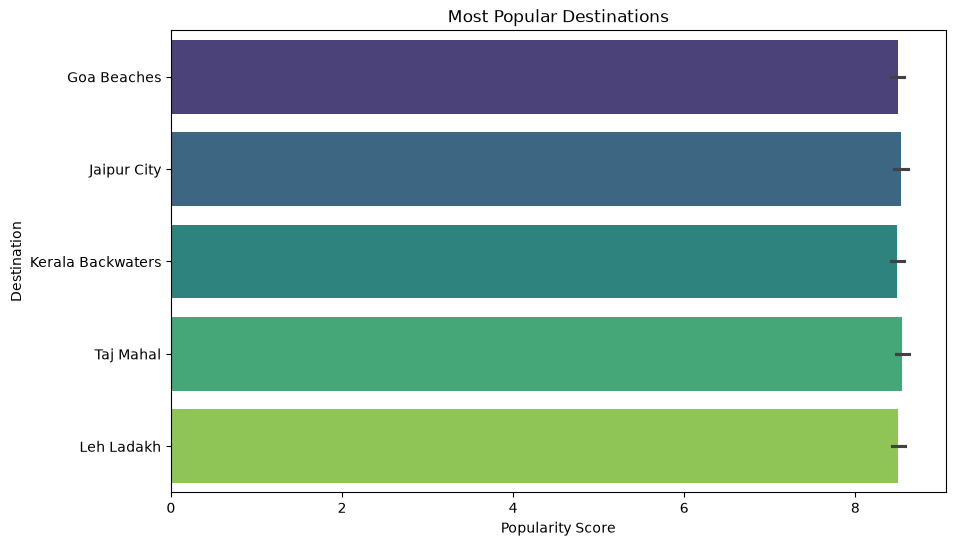

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x='Popularity', y='Name' , data= destinations_df.sort_values(by='Popularity', ascending=False), palette='viridis')
plt.title('Most Popular Destinations')
plt.xlabel('Popularity Score')
plt.ylabel('Destination')
plt.show()

C:\Users\PRAKHAR SINGH\AppData\Local\Temp\ipykernel_4900\3006445285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Type', data=destinations_df, order=destinations_df['Type'].value_counts().index,palette='coolwarm')


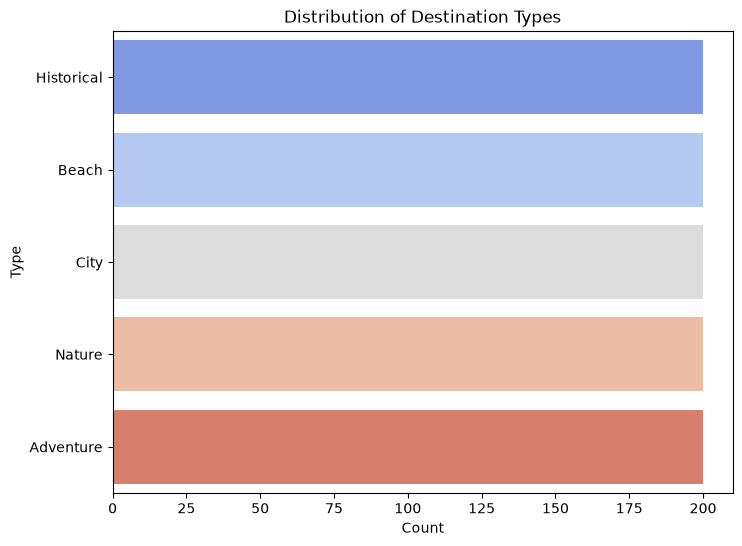

In [12]:
plt.figure(figsize= (8,6))
sns.countplot(y='Type', data=destinations_df, order=destinations_df['Type'].value_counts().index,palette='coolwarm')
plt.title('Distribution of Destination Types')
plt.xlabel('Count')
plt.ylabel('Type')
plt.show()

C:\Users\PRAKHAR SINGH\AppData\Local\Temp\ipykernel_4900\1474227100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='BestTimeToVisit', data=destinations_df, order=destinations_df['BestTimeToVisit'].value_counts().index,palette='plasma')


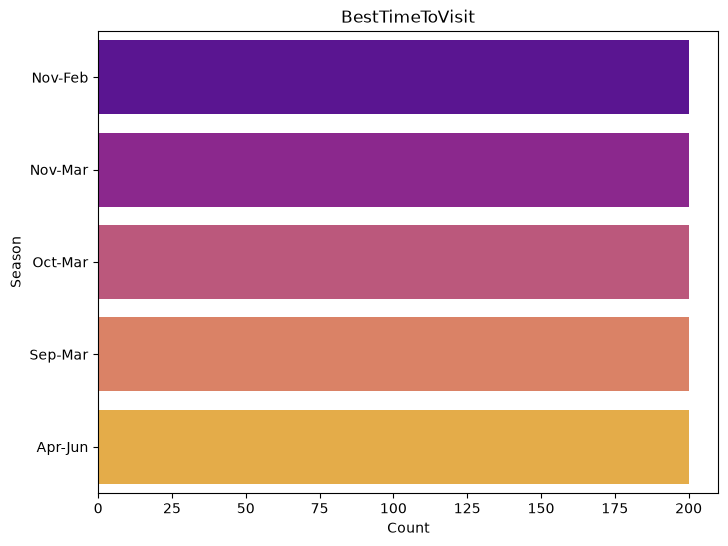

In [13]:
plt.figure(figsize= (8,6))
sns.countplot(y='BestTimeToVisit', data=destinations_df, order=destinations_df['BestTimeToVisit'].value_counts().index,palette='plasma')
plt.title('BestTimeToVisit')
plt.xlabel('Count')
plt.ylabel('Season')
plt.show()

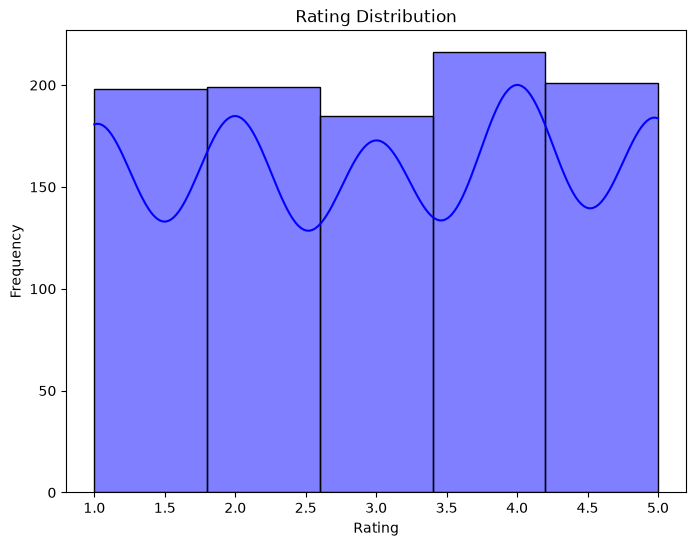

In [14]:
plt.figure(figsize= (8,6))
sns.histplot(reviews_df['Rating'], bins=5 , kde=True, color='blue')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [15]:
df['Features'] = df['Type'] + " " + df['State'] + " " + df['BestTimeToVisit'] + " " + df['Preferences']

In [16]:
vectorizer = TfidfVectorizer(stop_words='english')

destination_features = vectorizer.fit_transform(df['Features'])

cosine_sim = cosine_similarity(destination_features, destination_features)

In [17]:
def recommend_destinations(user_id, userhistory_df, destinations_df, cosine_sim):
    visited_destinations = userhistory_df[userhistory_df['UserID'] == user_id]['DestinationID'].values
    similar_scores = np.sum(cosine_sim[visited_destinations - 1], axis=0)
    recommended_destinations_idx = np.argsort(similar_scores)[::-1]
    recommendations = []
    for idx in recommended_destinations_idx:
        if destinations_df.iloc[idx]['DestinationID'] not in visited_destinations:
            recommendations.append(destinations_df.iloc[idx][[
                'DestinationID', 'Name', 'State', 'Type', 'Popularity', 'BestTimeToVisit'
            ]].to_dict())
            if len(recommendations) >= 5:
                break

    return pd.DataFrame(recommendations)  


recommended_destinations = recommend_destinations(10, userhistory_df, destinations_df, cosine_sim)
recommended_destinations

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,993,Jaipur City,Rajasthan,City,8.195155,Oct-Mar
1,326,Taj Mahal,Uttar Pradesh,Historical,8.206422,Nov-Feb
2,339,Kerala Backwaters,Kerala,Nature,8.568613,Sep-Mar
3,338,Jaipur City,Rajasthan,City,8.139655,Oct-Mar
4,337,Goa Beaches,Goa,Beach,8.576363,Nov-Mar


In [18]:
user_item_matrix = userhistory_df.pivot(index='UserID', columns='DestinationID', values='ExperienceRating')
user_item_matrix.fillna(0, inplace=True)
user_similarity = cosine_similarity(user_item_matrix)


In [19]:
def collaborative_recommend(user_id, user_similarity, user_item_matrix, destinations_df):
    similar_users = user_similarity[user_id -1]
    similar_users_idx = np.argsort(similar_users)[::-1][1:6]
    similar_user_ratings = user_item_matrix.iloc[similar_users_idx].mean(axis=0)
    recommended_destinations_ids = similar_user_ratings.sort_values(ascending=False).head(5).index
    recommendations = destinations_df[destinations_df['DestinationID'].isin(recommended_destinations_ids)][[
    'DestinationID', 'Name', 'State', 'Type', 'Popularity','BestTimeToVisit'
    ]]
    return recommendations
collaborative_recommendations = collaborative_recommend(1, user_similarity, user_item_matrix, destinations_df)
collaborative_recommendations


,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
335,336,Taj Mahal,Uttar Pradesh,Historical,9.268792,Nov-Feb
519,520,Leh Ladakh,Jammu and Kashmir,Adventure,8.521876,Apr-Jun
684,685,Leh Ladakh,Jammu and Kashmir,Adventure,7.598827,Apr-Jun
784,785,Leh Ladakh,Jammu and Kashmir,Adventure,9.366933,Apr-Jun
878,879,Kerala Backwaters,Kerala,Nature,8.309631,Sep-Mar


In [20]:
collaborative_recommendations = collaborative_recommend(15, user_similarity, user_item_matrix, destinations_df)
collaborative_recommendations


,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
10,11,Taj Mahal,Uttar Pradesh,Historical,8.177709,Nov-Feb
519,520,Leh Ladakh,Jammu and Kashmir,Adventure,8.521876,Apr-Jun
684,685,Leh Ladakh,Jammu and Kashmir,Adventure,7.598827,Apr-Jun
784,785,Leh Ladakh,Jammu and Kashmir,Adventure,9.366933,Apr-Jun
810,811,Taj Mahal,Uttar Pradesh,Historical,9.393806,Nov-Feb


In [21]:
collaborative_recommendations = collaborative_recommend(100, user_similarity, user_item_matrix, destinations_df)
collaborative_recommendations


,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
5,6,Taj Mahal,Uttar Pradesh,Historical,7.648950,Nov-Feb
346,347,Goa Beaches,Goa,Beach,7.920960,Nov-Mar
519,520,Leh Ladakh,Jammu and Kashmir,Adventure,8.521876,Apr-Jun
684,685,Leh Ladakh,Jammu and Kashmir,Adventure,7.598827,Apr-Jun
784,785,Leh Ladakh,Jammu and Kashmir,Adventure,9.366933,Apr-Jun


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
data = df.copy()


In [23]:
features = ['Name_x', 'State', 'Type', 'BestTimeToVisit', 'Preferences', 'Gender', 'NumberOfAdults', 'NumberOfChildren']
target = 'Popularity'

In [24]:
label_encoder= {}
for col in features:
    if data[col].dtype=='object':
        le= LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoder[col] = le

In [25]:
X = data[features]
y = data[target]


X_train, X_test , y_train, y_test = train_test_split(X,y, test_size=0.2 , random_state=42)

In [26]:
X = X.drop(columns=['Name_x'], errors='ignore')
X = pd.get_dummies(X, columns=['State', 'Type', 'BestTimeToVisit', 'Preferences', 'Gender'], drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE :", mean_squared_error(y_test, y_pred))

MSE : 0.30073151670563464


In [27]:
def recommend_destinations(user_input, model, X_train_columns):
    input_df = pd.DataFrame([user_input])
    input_df = pd.get_dummies(input_df, columns=['State', 'Type', 'BestTimeToVisit', 'Preferences', 'Gender'])
    input_df = input_df.reindex(columns=X_train_columns, fill_value=0)
    predicted_popularity = model.predict(input_df)[0]
    return predicted_popularity


user_input = {
    'Type': 'City',
    'State': 'Rajasthan',
    'BestTimeToVisit': 'Oct-Mar',
    'Preferences': 'City, Historical',
    'Gender': 'Female',
    'NumberOfAdults': 2,
    'NumberOfChildren': 1,
}

predicted_popularity = recommend_destinations(user_input, model, X_train.columns)
print(f"Predicted Popularity Score: {predicted_popularity:.2f}")

Predicted Popularity Score: 7.87


In [31]:
import pickle
pickle.dump(model, open("model.pkl","wb"))
pickle.dump(list(X_train.columns), open("model_columns.pkl", "wb"))

In [33]:
model = pickle.load(open("model.pkl", "rb"))
model_columns = pickle.load(open("model_columns.pkl", "rb"))


predicted_popularity = recommend_destinations(user_input, model, model_columns)